# **HIERARICHAL CLUSTERING - UNSUPERVISED LEARNING**

---

<br>

## 1. Hierarchical Clustering

**Concept**:  
Hierarchical clustering is an unsupervised method that builds a tree of clusters. You don’t need to pre-define the number of clusters. It shows how data points group together at different levels of similarity.

**Types**:
- **Agglomerative (Bottom-Up)**:  
  Starts with each data point as its own cluster and merges the most similar clusters until all points are in one cluster.
  
- **Divisive (Top-Down)**:  
  Starts with one cluster and splits it into smaller clusters until each data point is its own cluster.

**Linkage Methods**:
- **Ward**:  
  Minimizes the increase in variance inside clusters. Produces compact clusters.
  
- **Single**:  
  Measures the distance between the closest points of two clusters. May create elongated clusters.
  
- **Complete**:  
  Measures the distance between the farthest points of two clusters. Often produces compact clusters.
  
- **Average**:  
  Measures the average distance between all points in two clusters.

**Output**:  
A hierarchical tree structure called a **dendrogram**.

<br>

---

<br>

## 2. Dendrogram

**Purpose**:  
A **dendrogram** is a tree-like diagram showing the hierarchy of clusters created by hierarchical clustering.

**Structure**:
- **Branches**: Represent clusters.
- **Merging Points**: Height at which two branches merge indicates the distance between clusters. The lower the merge, the more similar the clusters.
- **Leaves**: Represent individual data points at the bottom.
- **Vertical Lines**: Show the distance between clusters.

**Interpretation**:
- **Cluster Similarity**: Clusters merging lower in the tree are more similar.
- **Choosing Clusters**: You can "cut" the tree at a certain height to define clusters. The number of clusters is the number of vertical lines the horizontal line intersects.

<br>

---

<br>

## 3. Principal Component Analysis (PCA)

**Purpose**:  
PCA reduces the number of features in data while keeping the important information. It helps to visualize high-dimensional data and improve clustering.

**How it Works**:  
- PCA finds the main directions (principal components) in the data that explain the most variance.
- It projects the data onto these new directions.

**In Clustering**:
- **Visualization**: Reduces the data to 2 or 3 dimensions to plot clusters.
- **Noise Reduction**: Removes unimportant dimensions to reduce noise.
- **Faster Performance**: Using fewer dimensions speeds up clustering.
- **Not Always Needed**: PCA is helpful when you have many features, not always required for smaller datasets.

<br>

---

<br>

## 4. Silhouette Score

**Purpose**:  
The **Silhouette Score** helps measure how good the clusters are.

**How it Works**:
- For each data point:
  - **Cohesion**: How close the point is to others in the same cluster.
  - **Separation**: How far the point is from the nearest cluster.
  
**Silhouette Coefficient**:  
Ranges from **-1** to **+1**:
- **+1**: Point is well matched to its cluster.
- **0**: Point is close to the boundary between two clusters.
- **-1**: Point is likely in the wrong cluster.

**Overall Score**:  
Average silhouette score of all points shows the quality of the clusters.

**Using in Hierarchical Clustering**:  
Run hierarchical clustering with different numbers of clusters, calculate the silhouette score for each, and pick the K that has the highest score.

<br>

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

In [2]:
iris = datasets.load_iris()

In [3]:
iris_data = pd.DataFrame(iris.data)

In [4]:
iris_data.coloums=iris.feature_names

<ipython-input-4-1ad42c5fe6e2>:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  iris_data.coloums=iris.feature_names


In [5]:
iris_data

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [6]:
# Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [7]:
X_scaled = scaler.fit_transform(iris_data)

In [8]:
X_scaled

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

In [9]:
X_scaled.shape

(150, 4)

In [10]:
# Dimensionality Reduction
# PCA is used to convert the Dimension of the data
from sklearn.decomposition import PCA

In [11]:
# So we are having 4-Dimension of data and we will convert it into 2-Dimensions
pca = PCA(n_components=2)

In [12]:
pca_scaled=pca.fit_transform(X_scaled)

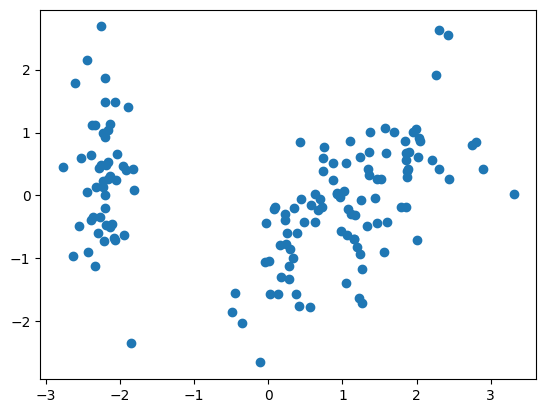

In [13]:
plt.scatter(pca_scaled[:,0],pca_scaled[:,1])

## Agglomerative Clustering

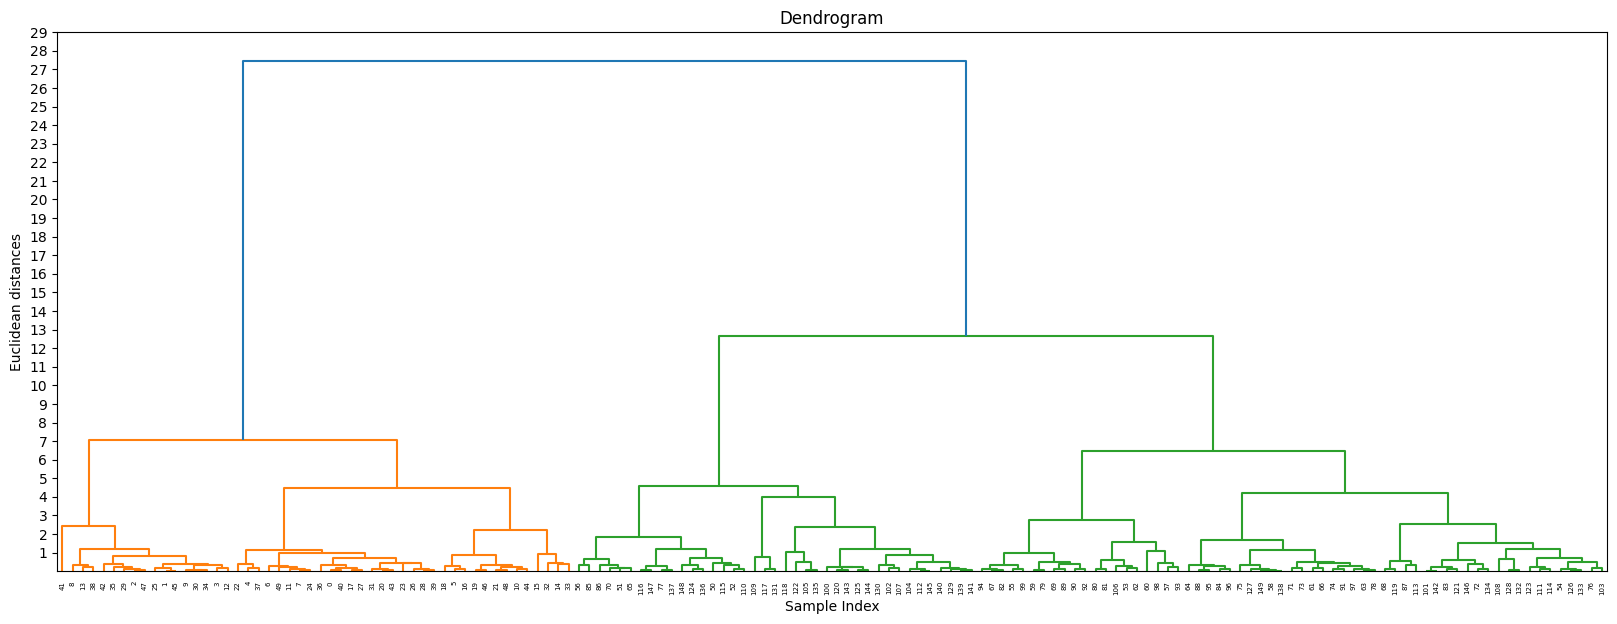

In [14]:
# To construct a dendogram
import scipy.cluster.hierarchy as sch

# Plot the dendogram
plt.figure(figsize = (20, 7))
plt.title("Dendograms")

# Create Dendogram
sch.dendrogram(sch.linkage(pca_scaled, method = 'ward'))
plt.title('Dendrogram')
plt.yticks(range(1,30))
plt.xlabel('Sample Index')
plt.ylabel('Euclidean distances')
plt.show()

So you can select the longest vertical line such that no horizontal line passes through it.
In our case (13 - 28) is the longest vertical line and it passes from 2 lines
so `[("n_clusters = 2" or "k=2")]`

In [15]:
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters = 2, metric = 'euclidean', linkage = 'ward')
cluster.fit(pca_scaled)

AgglomerativeClustering()

In [16]:
cluster.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

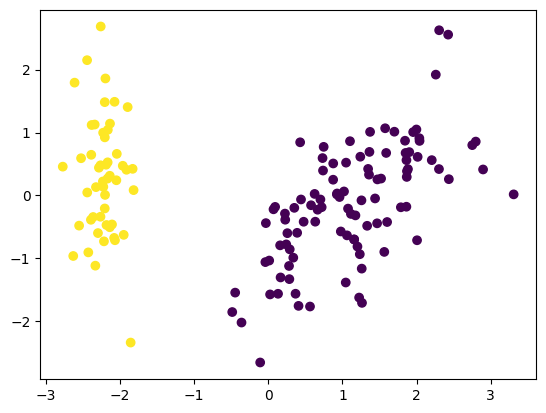

In [17]:
plt.scatter(pca_scaled[:,0],pca_scaled[:,1],c=cluster.labels_)

Silhouette Score

In [18]:
from sklearn.metrics import silhouette_score

In [19]:
silhouette_coefficients=[]
for k in range(2,11):
  agglo = AgglomerativeClustering(n_clusters = k, metric = 'euclidean', linkage = 'ward')
  agglo.fit(X_scaled)
  score = silhouette_score(X_scaled, agglo.labels_)
  silhouette_coefficients.append(score)

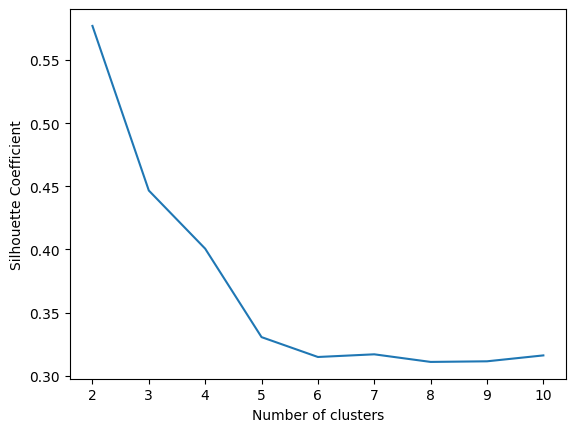

In [20]:
## Ploting Silhouette Score
plt.plot(range(2,11), silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Coefficient')
plt.show()

# **So, You can see `2` has highest Accuracy**